<a href="https://colab.research.google.com/github/eyradel/-Real-time-remote-prediction-of-cable-breaks-in-telecommunication-systems/blob/main/notebooks/train-yolo26-instance-segmentation-on-custom-dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO26 Instance Segmentation on a Custom Dataset

---

[![roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/train-yolo26-instance-segmentation-custom-data/) [![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO26 introduces a unified architecture designed to support detection, segmentation, and pose tasks within a single model family. The model uses an anchor-free design with a decoupled head.

## Setup

### Configure API keys

To fine-tune YOLO26, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Runtime` -> `Change runtime type` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Mon Sep 28 14:02:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


### Install dependencies required for YOLO26

In [3]:
!pip install -q "ultralytics>=8.4.0" supervision roboflow

# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/112.6 GB disk)


### Download example data

Downloads example images for testing. You can use these or replace them with your own images.

In [4]:
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg

## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

In [5]:
!yolo task=segment mode=predict model=yolo26m-seg.pt source={HOME}/dog-3.jpeg save=True verbose=False

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-seg summary (fused): 146 layers, 23,569,148 parameters, 0 gradients, 121.7 GFLOPs
Results saved to /content/runs/segment/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


**NOTE:** Result annotated image got saved in `{HOME}/runs/segment/predict/`. Let's display it.

In [6]:
!ls -la {HOME}/runs/segment/predict/

total 448
drwxr-xr-x 2 root root   4096 Sep 28 14:03 .
drwxr-xr-x 3 root root   4096 Sep 28 14:02 ..
-rw-r--r-- 1 root root 450146 Sep 28 14:03 dog-3.jpg


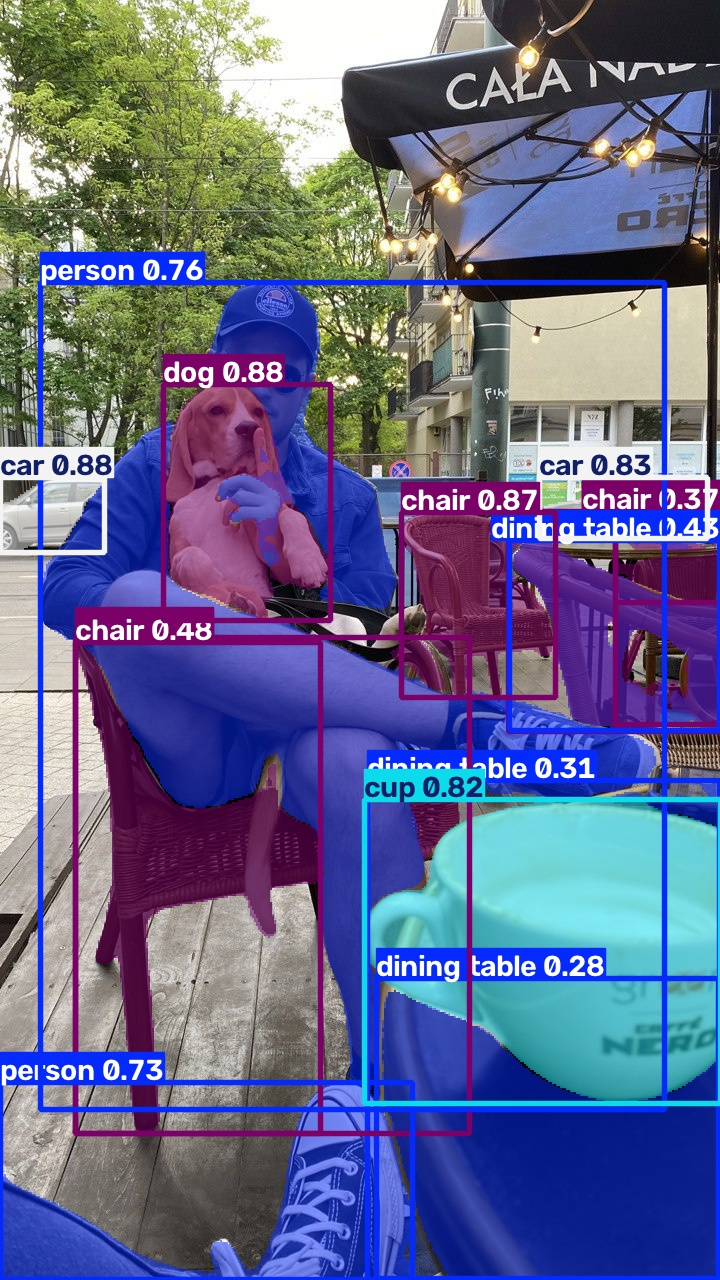

In [7]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/segment/predict/dog-3.jpg', width=600)

### SDK

**NOTE:** YOLO's Python interface allows for seamless integration into your Python projects, making it easy to load, run, and process the model's output.

In [8]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo26m-seg.pt')
image = Image.open(f'{HOME}/dog-3.jpeg')
result = model.predict(image, verbose=False)[0]

**NOTE:** The obtained `result` object stores information about the location, classes, and confidence levels of the detected objects.

In [9]:
result.boxes.xyxy

tensor([[3.5324e-02, 4.7737e+02, 1.0489e+02, 5.5211e+02],
        [1.6317e+02, 3.8441e+02, 3.3052e+02, 6.2032e+02],
        [4.0188e+02, 5.1213e+02, 5.5512e+02, 6.9735e+02],
        [5.3972e+02, 4.7762e+02, 7.0746e+02, 5.3884e+02],
        [3.6477e+02, 7.9911e+02, 7.2000e+02, 1.1034e+03],
        [4.0150e+01, 2.8290e+02, 6.6416e+02, 1.1096e+03],
        [5.6543e-01, 1.0820e+03, 4.1216e+02, 1.2797e+03],
        [7.5298e+01, 6.4266e+02, 3.2095e+02, 1.1332e+03],
        [5.0993e+02, 5.4003e+02, 7.1979e+02, 7.3047e+02],
        [7.5162e+01, 6.3768e+02, 4.6912e+02, 1.1335e+03],
        [6.1912e+02, 5.1160e+02, 7.1939e+02, 5.3969e+02],
        [5.0821e+02, 5.3983e+02, 7.2000e+02, 7.3140e+02],
        [6.1518e+02, 5.1146e+02, 7.2000e+02, 7.2451e+02],
        [3.6788e+02, 7.8060e+02, 7.1928e+02, 1.2794e+03],
        [3.7684e+02, 9.7886e+02, 7.1858e+02, 1.2789e+03],
        [6.1587e+02, 5.1097e+02, 7.2000e+02, 6.0243e+02]], device='cuda:0')

In [10]:
result.boxes.conf

tensor([0.8834, 0.8758, 0.8743, 0.8269, 0.8234, 0.7605, 0.7330, 0.4836, 0.4300, 0.3853, 0.3719, 0.3587, 0.3232, 0.3108, 0.2754, 0.2548], device='cuda:0')

In [11]:
result.boxes.cls

tensor([ 2., 16., 56.,  2., 41.,  0.,  0., 56., 60., 56., 56., 56., 56., 60., 60., 56.], device='cuda:0')

In [12]:
result.masks.data.shape

torch.Size([16, 640, 384])

**NOTE:** YOLO26 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [13]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

In [14]:
import supervision as sv
from PIL import Image

def annotate(image: Image.Image, detections: sv.Detections) -> Image.Image:
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    mask_annotator = sv.MaskAnnotator()
    polygon_annotator = sv.PolygonAnnotator(color=sv.Color.WHITE)
    label_annotator = sv.LabelAnnotator(
        text_color=sv.Color.BLACK,
        text_scale=text_scale,
        text_position=sv.Position.CENTER_OF_MASS
    )

    out = image.copy()
    out = mask_annotator.annotate(out, detections)
    out = polygon_annotator.annotate(out, detections)
    out = label_annotator.annotate(out, detections)
    out.thumbnail((1000, 1000))
    return out

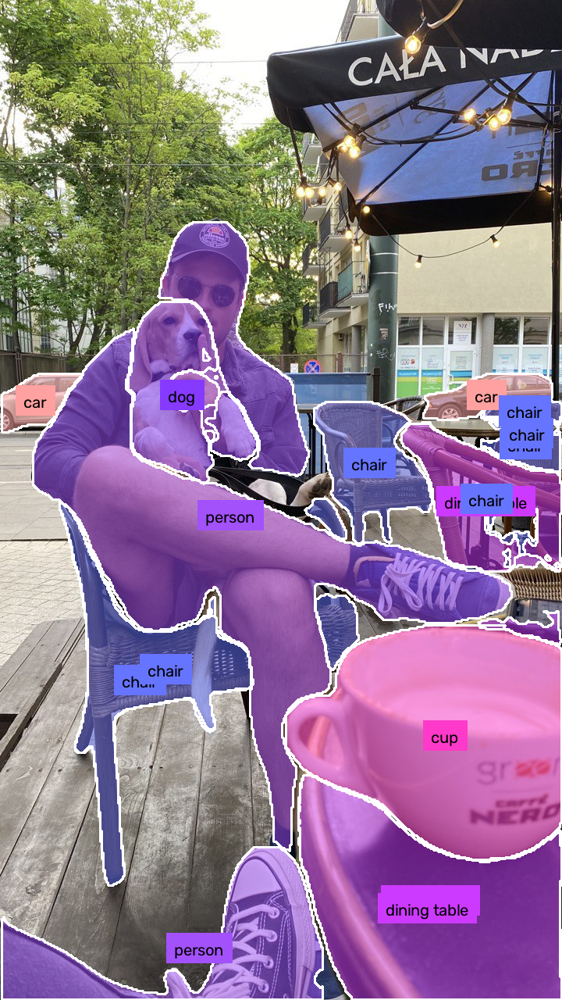

In [15]:
annotated_image = annotate(image, detections)
annotated_image

## Fine-tune YOLO26 on custom dataset

**NOTE:** When training YOLO26, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [16]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('mlbnMQgkERwfucc0PEAL')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("rust-detection")
project = workspace.project("rust-detection-38s6e")
version = project.version(4)
dataset = version.download("yolo26")


/content/datasets


SecretNotFoundError: Secret ROBOFLOW_API_KEY does not exist.

## Custom Training

In [ ]:
%cd {HOME}

!yolo task=segment mode=train model=yolo26m-seg.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 plots=True

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [ ]:
!ls {HOME}/runs/segment/train/

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/segment/train/confusion_matrix.png', width=600)

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/segment/train/results.png', width=600)

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/segment/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [ ]:
!yolo task=segment mode=val model={HOME}/runs/segment/train/weights/best.pt data={dataset.location}/data.yaml

## Inference with custom model

### CLI

In [ ]:
!yolo task=segment mode=predict model={HOME}/runs/segment/train/weights/best.pt source={dataset.location}/test/images save=True verbose=False

### SDK

In [ ]:
from ultralytics import YOLO

model = YOLO(f'{HOME}/runs/segment/train/weights/best.pt')

In [ ]:
import supervision as sv

ds_test = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml",
    force_masks=True
)

In [ ]:
import supervision as sv
from PIL import Image

def annotate(image: Image.Image, detections: sv.Detections) -> Image.Image:
    color = sv.ColorPalette.from_hex([
        "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00",
        "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    ])

    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    mask_annotator = sv.MaskAnnotator()
    polygon_annotator = sv.PolygonAnnotator(color=sv.Color.WHITE)
    label_annotator = sv.LabelAnnotator(
        text_color=sv.Color.BLACK,
        text_scale=text_scale,
        text_position=sv.Position.CENTER_OF_MASS
    )

    out = image.copy()
    out = mask_annotator.annotate(out, detections)
    out = polygon_annotator.annotate(out, detections)
    out = label_annotator.annotate(out, detections)
    out.thumbnail((1000, 1000))
    return out

In [ ]:
import random
import matplotlib.pyplot as plt

N = 9
L = len(ds_test)

annotated_images = []

for i in random.sample(range(L), N):
    path, _, annotations = ds_test[i]
    image = Image.open(path)
    result = model.predict(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(result)
    annotated_image = annotate(image, detections)
    annotated_images.append(annotated_image)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, img in zip(axes.flat, annotated_images):
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.01, right=0.99, top=0.99, bottom=0.01)

plt.show()

In [ ]:
annotated_images[0]

## Deploy model on Roboflow

Upload the YOLO26 weights to Roboflow Deploy for inference on Roboflow infrastructure built for scale.

In [ ]:
project.version(dataset.version).deploy(model_type="yolo26", model_path=f"{HOME}/runs/segment/train/")

## Run inference with a Roboflow hosted model

Load a trained model from Roboflow and run inference.

In [ ]:
!pip install -q inference

In [ ]:
from inference import get_model
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

model_id = project.id.split("/")[1] + "/" + dataset.version
model = get_model(model_id, ROBOFLOW_API_KEY)

In [ ]:
import random
import matplotlib.pyplot as plt

N = 9
L = len(ds_test)

annotated_images = []

for i in random.sample(range(L), N):
    path, _, annotations = ds_test[i]
    image = Image.open(path)
    result = model.infer(image)[0]
    detections = sv.Detections.from_inference(result)
    annotated_image = annotate(image, detections)
    annotated_images.append(annotated_image)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, img in zip(axes.flat, annotated_images):
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.01, right=0.99, top=0.99, bottom=0.01)

plt.show()

In [ ]:
annotated_images[0]

<div align="center">
  <p>
    Looking for more tutorials or have questions?
    Check out our <a href="https://github.com/roboflow/notebooks">GitHub repo</a> for more notebooks,
    or visit our <a href="https://discord.gg/GbfgXGJ8Bk">discord</a>.
  </p>
  
  <p>
    <strong>If you found this helpful, please consider giving us a ⭐
    <a href="https://github.com/roboflow/notebooks">on GitHub</a>!</strong>
  </p>

</div>